# RQ2 — Political Stance Shift (cross-model analysis)

**RQ2: Do LLM-generated summaries shift the political stance of the original article?**

This notebook answers **RQ2a** for the three large models from Liscio et al. (2025):
for each model and leaning we test whether the mean stance shift (summary − article)
differs from zero, accounting for the fact that the same article is summarized many
times (once per prompting method).

The complementary question — **RQ2b, does (moral-aware / few-shot) prompting reduce
the shift?** — is answered in `RQ2_llama8b_prompting_strategies.ipynb`, where all
prompting strategies (the paper's baselines and our proposed few-shot variants) are
compared head-to-head on a single model.

**Stance scores.** Each text is scored by `politicalBiasBERT` into `P(left)`,
`P(center)`, `P(right)`. We summarize stance with `direction = P(right) − P(left)`
(+1 right, −1 left) and `polarization = 1 − P(center)` (0 = centrist). The *shift* is
the within-article difference, `summary − article`.

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import wilcoxon

# --- Paths ---
REPO_ROOT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SHIFTS_PATH = REPO_ROOT / 'political_shift' / 'data' / 'shifts.parquet'

# --- Constants ---
METHOD_ORDER  = ['vanilla', 'simple', 'cot', 'oracle', 'class']
LEANING_ORDER = ['center', 'left', 'right']        # center = reference level
MODEL_IDS = [
    'Meta-Llama-3-70B-Instruct',
    'c4ai-command-r-plus-4bit',
    'DeepSeek-R1-Distill-Qwen-32B',
]
LEANING_COLORS = {'left': '#3b76d1', 'center': '#7e7e7e', 'right': '#c83e3e'}

shifts = pd.read_parquet(SHIFTS_PATH)
shifts = shifts[shifts['model'].isin(MODEL_IDS)]  # 8B analysed in its own notebook
print(f'{len(shifts):,} rows  '
      f"({shifts['model'].nunique()} models x {shifts['method'].nunique()} methods x "
      f"{shifts['article_id'].nunique()} articles x {shifts['seed'].nunique()} seeds)")
shifts[['article_id','leaning','method','model','seed','direction_shift','polarization_shift']].head(3)

10,882 rows  (3 models x 5 methods x 180 articles x 5 seeds)


,article_id,leaning,method,model,seed,direction_shift,polarization_shift
0,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,311,-0.141241,0.605849
1,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,345,-0.134459,0.053827
2,allsides_abortion_c_2,center,class,DeepSeek-R1-Distill-Qwen-32B,49,-0.087914,0.211493


### Analysis unit: average the seeds

Each (article, method, model) cell is generated over 5 random seeds. Seeds are
replicates, not independent observations, so we average them to one value per cell
before any test. The remaining repetition (the same article appearing once per method)
is handled by a per-article random intercept in the models below.

In [2]:
def seed_average(model_id):
    """Collapse the 5 seeds -> one row per (article, leaning, method)."""
    ag = (shifts[shifts['model'] == model_id]
          .groupby(['article_id', 'leaning', 'method'], observed=True)
          .agg(direction_shift=('direction_shift', 'mean'),
               polarization_shift=('polarization_shift', 'mean'))
          .reset_index())
    ag['method']  = pd.Categorical(ag['method'],  categories=METHOD_ORDER)
    ag['leaning'] = pd.Categorical(ag['leaning'], categories=LEANING_ORDER)
    return ag

# Sanity check on the primary model.
_ex = seed_average('Meta-Llama-3-70B-Instruct')
print(f'Llama: {len(_ex)} rows ({_ex.article_id.nunique()} articles)')

Llama: 749 rows (180 articles)


## RQ2a — Do summaries shift the political stance?

For each (model, leaning, outcome) we fit an intercept-only linear mixed-effects model
with a random intercept per article:

```
shift ~ 1,  (1 | article_id)
```

The intercept is the mean shift for that group, and its p-value tests whether that mean
differs from zero. The random intercept stops the repeated methods within an article
from being counted as independent evidence. A significant non-zero intercept means
summaries systematically move the stance for that leaning.

In [3]:
rows = []
for mid in MODEL_IDS:
    ag = seed_average(mid)
    for outcome in ['direction_shift', 'polarization_shift']:
        for lean in LEANING_ORDER:
            sub = ag[ag['leaning'] == lean]
            res = smf.mixedlm(f'{outcome} ~ 1', sub, groups=sub['article_id']).fit(reml=True)
            p = res.pvalues['Intercept']
            rows.append({
                'model':   mid.split('-')[0],
                'outcome': outcome.replace('_shift', ''),
                'leaning': lean,
                'mean_shift': round(res.params['Intercept'], 3),
                'p': round(p, 4),
                'sig (p<.05)': '*' if p < 0.05 else '',
            })

rq2a = pd.DataFrame(rows)
rq2a

/Users/kunalnarwani/miniforge3/envs/LLMs/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


,model,outcome,leaning,mean_shift,p,sig (p<.05)
0,Meta,direction,center,0.173,0.0070,*
1,Meta,direction,left,0.312,0.0001,*
2,Meta,direction,right,0.005,0.9365,
3,Meta,polarization,center,0.247,0.0000,*
4,Meta,polarization,left,-0.062,0.0339,*
5,Meta,polarization,right,-0.023,0.3017,
6,c4ai,direction,center,0.095,0.1622,
7,c4ai,direction,left,0.248,0.0003,*
8,c4ai,direction,right,-0.023,0.6771,
9,c4ai,polarization,center,0.257,0.0000,*


In [4]:
# Readable view: mean shift per model x leaning, with * marking p < 0.05.
disp = rq2a.assign(val=rq2a['mean_shift'].astype(str) + rq2a['sig (p<.05)'])
disp.pivot_table(index=['model', 'leaning'], columns='outcome',
                 values='val', aggfunc='first')

outcome          direction polarization
model    leaning                       
DeepSeek center      0.092       0.124*
         left       0.265*      -0.175*
         right     -0.132*      -0.159*
Meta     center     0.173*       0.247*
         left       0.312*      -0.062*
         right       0.005       -0.023
c4ai     center      0.095       0.257*
         left       0.248*       -0.046
         right      -0.023       -0.035

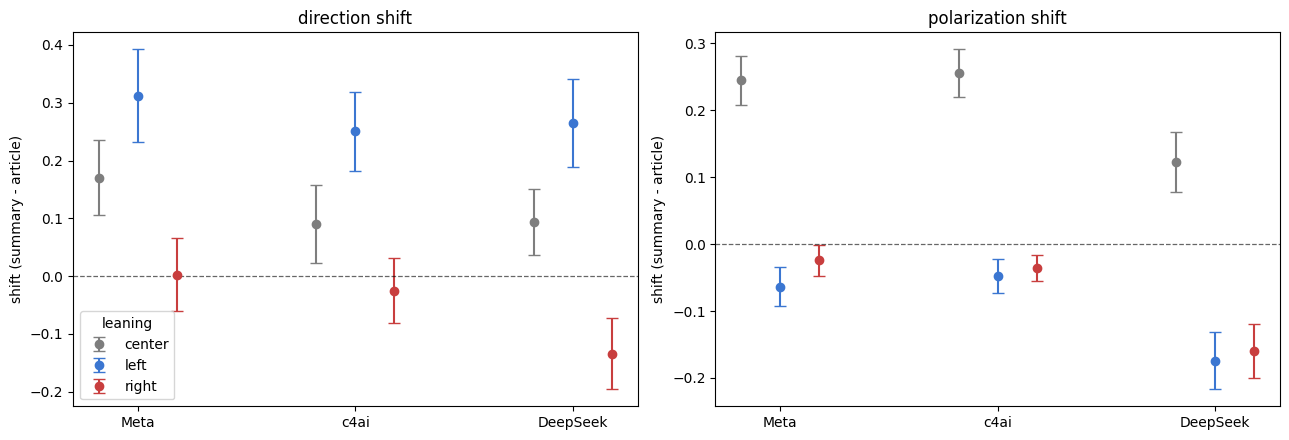

In [5]:
# Visual: mean shift +/- 95% CI by leaning, per model, for both outcomes.
def mean_ci(v):
    v = np.asarray(v, float); return v.mean(), 1.96 * v.std(ddof=1) / np.sqrt(len(v))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, outcome in zip(axes, ['direction_shift', 'polarization_shift']):
    for i, mid in enumerate(MODEL_IDS):
        ag = seed_average(mid)
        for j, lean in enumerate(LEANING_ORDER):
            mu, half = mean_ci(ag[ag['leaning'] == lean][outcome])
            ax.errorbar(i + (j-1)*0.18, mu, yerr=half, fmt='o', ms=6, capsize=4,
                        color=LEANING_COLORS[lean],
                        label=lean if i == 0 else None)
    ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.6)
    ax.set_xticks(range(len(MODEL_IDS)))
    ax.set_xticklabels([m.split('-')[0] for m in MODEL_IDS])
    ax.set_title(outcome.replace('_', ' '))
    ax.set_ylabel('shift (summary - article)')
axes[0].legend(title='leaning')
fig.tight_layout(); plt.show()

### RQ2a — what the numbers say

Two effects are significant in **all three models**:

- **Left articles are pulled rightward** (positive `direction` shift, ~+0.25 to +0.31):
  summaries of left-leaning articles read as less left than the source.
- **Center articles gain polarization** (positive `polarization` shift, ~+0.12 to +0.26):
  neutral articles are pushed to take a side they did not originally take.

Right-leaning articles move least (their `direction` shift is significant only for
DeepSeek), and left/right articles tend to *lose* polarization (moderation).

**Answer to RQ2a: yes.** Summaries systematically shift political stance, in an
asymmetric *regression-to-center* pattern — the extremes are pulled toward the middle
and neutral copy is pushed off-center — and the pull is stronger on the left than the
right.

### Full breakdown by method × leaning

The plot above collapses over prompting methods. Here we break the shift out by method
as well, for all three models and both outcomes, to show that the shift pattern is not
driven by any single prompting method. These are descriptive means ± 95% CI — the formal
test is the RQ2a intercept test above; the formal method comparison (RQ2b) is in
`RQ2_llama8b_prompting_strategies.ipynb`.

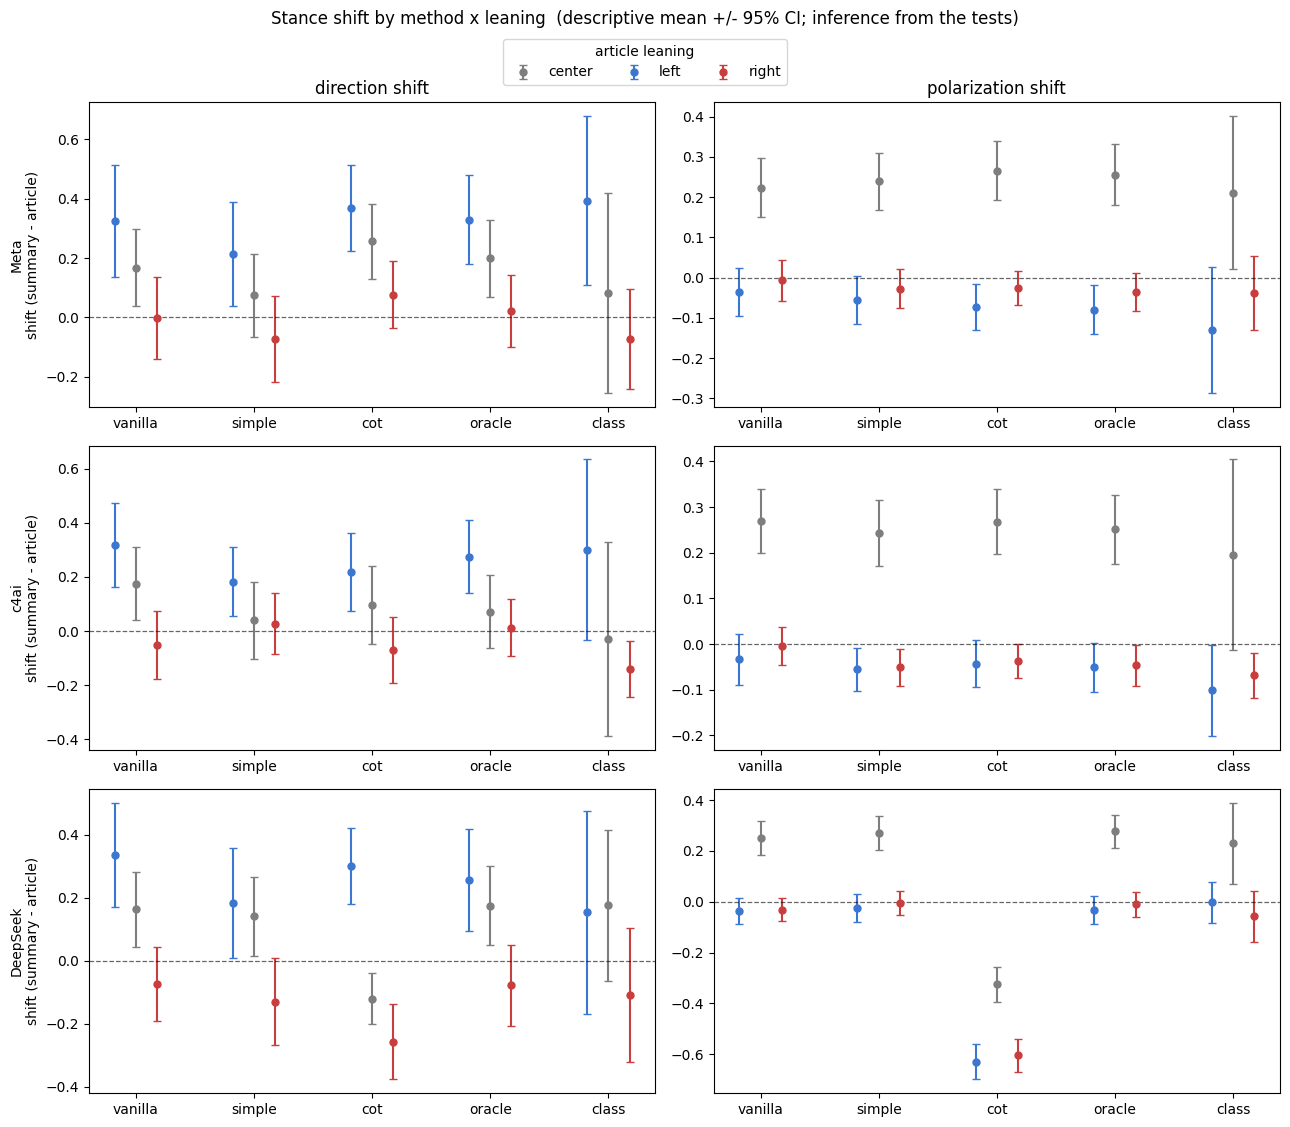

In [6]:
def _mean_ci(v):
    v = np.asarray(v, float)
    return v.mean(), 1.96 * v.std(ddof=1) / np.sqrt(len(v))

JITTER = {'left': -0.18, 'center': 0.0, 'right': 0.18}
fig, axes = plt.subplots(len(MODEL_IDS), 2, figsize=(13, 11))
for r, mid in enumerate(MODEL_IDS):
    ag = seed_average(mid)
    for c, outcome in enumerate(['direction_shift', 'polarization_shift']):
        ax = axes[r, c]
        for lean in LEANING_ORDER:
            xs, ys, es = [], [], []
            for k, method in enumerate(METHOD_ORDER):
                sub = ag[(ag['leaning'] == lean) & (ag['method'] == method)][outcome]
                mu, half = _mean_ci(sub)
                xs.append(k + JITTER[lean]); ys.append(mu); es.append(half)
            ax.errorbar(xs, ys, yerr=es, fmt='o', ms=5, capsize=3,
                        color=LEANING_COLORS[lean],
                        label=lean if (r == 0 and c == 0) else None)
        ax.axhline(0, color='black', lw=0.9, ls='--', alpha=0.6)
        ax.set_xticks(range(len(METHOD_ORDER))); ax.set_xticklabels(METHOD_ORDER)
        if c == 0:
            ax.set_ylabel(f"{mid.split('-')[0]}\nshift (summary - article)")
        if r == 0:
            ax.set_title(outcome.replace('_', ' '))
fig.legend(title='article leaning', loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.0))
fig.suptitle('Stance shift by method x leaning  (descriptive mean +/- 95% CI; inference from the tests)',
             y=1.02)
fig.tight_layout()
plt.show()

## Conclusion

**RQ2a — Do summaries shift the political stance? Yes.** The shift is systematic and
consistent across all three models: a *regression-to-center* pattern that pulls
left-leaning articles rightward (~+0.25 to +0.31) and pushes neutral articles to take
a side (polarization +0.12 to +0.26), with the pull stronger on the left than the
right. The pattern holds across all prompting methods.

**RQ2b** (whether moral-aware or few-shot prompting reduces this shift) is answered in
`RQ2_llama8b_prompting_strategies.ipynb`: no strategy reliably reduces it.